
# Tracks-Only Pipeline — **UMAP → HDBSCAN → Random Forest** (Interactive)
 

In [2]:

# ─── IMPORTS ───────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd


from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

import umap.umap_ as umap
import hdbscan

import plotly.express as px
import plotly.graph_objects as go

# Plotly setup for classic Jupyter Notebook
import plotly.io as pio
from plotly.offline import init_notebook_mode

pio.renderers.default = "notebook"   # inline in classic Notebook
init_notebook_mode(connected=True)   # load JS (uses CDN; set to False if fully offline)

# ─── 1) CONFIG ────────────────────────────────────────────────────────────────
from pathlib import Path
import re

# Directory containing all TRACKS CSVs (set this to your path)
TRACKS_DIR = Path('/Users/brianmah/Library/CloudStorage/OneDrive-UBC(2)/uQuB/Data Analysis/B Cell ML Work/B Cell M0 Raw files/Macrophage tracking/Tracks')  # <- CHANGE THIS

ASSET_DIR = "/Users/brianmah/Downloads"
# Track-level features to use (removed: "NUMBER_GAPS",)
FEATURES = [
     "NUMBER_SPOTS","NUMBER_SPLITS","TRACK_DURATION","TRACK_DISPLACEMENT",
    "TRACK_MEDIAN_SPEED","TOTAL_DISTANCE_TRAVELED","MEAN_DIRECTIONAL_CHANGE_RATE",
    "CONFINEMENT_RATIO"
]

# # UMAP params
# UMAP_PARAMS = dict(
#     n_neighbors=15,
#     min_dist=0.3,
#     n_components=2,
#     metric="euclidean",
#     random_state=42
# )

# # HDBSCAN params
# HDBSCAN_PARAMS = dict(
#     min_cluster_size=50,
#     min_samples=50,
#     cluster_selection_epsilon=0.0,
#     cluster_selection_method="eom"
# )

# TEST PARAMETERS
UMAP_PARAMS = dict(
    n_neighbors=40,
    min_dist=0.3,
    n_components=2,
    metric="euclidean",
    random_state=42
)

# TEST PARAMETERS
HDBSCAN_PARAMS = dict(
    min_cluster_size=75,
    min_samples=10,
    cluster_selection_method="eom"
)


# Random Forest params
RF_PARAMS = dict(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Example filename:
# 20240918_30um_M0_R1_tracks.csv

FLEX_REGEXES = [
    re.compile(r".*?(?P<size>30|60|90)\s*um.*?M0.*?(?P<rep>R[1-9]).*", re.IGNORECASE),
    re.compile(r".*?(?P<size>30|60|90).*?M0.*?(?P<rep>R[1-9]).*", re.IGNORECASE),
]

FILENAME_OVERRIDES = {
    # "example.csv": {"size": "60", "rep": "R1"},
}

def parse_tokens_from_name(fname: str):
    base = os.path.basename(fname)

    if base in FILENAME_OVERRIDES:
        o = FILENAME_OVERRIDES[base]
        return str(o["size"]), str(o["rep"]).upper()

    for rx in FLEX_REGEXES:
        m = rx.match(base)
        if m:
            size = str(int(m.group("size")))
            rep = m.group("rep").upper()
            return size, rep

    return None, None

def condition_label(size):
    return f"{size}um"

def condition_sort_key(label: str):
    try:
        return int(str(label).replace("um", ""))
    except Exception:
        return 0

In [3]:
from platform import python_version
print(python_version())

3.13.5


In [4]:
csvs = sorted([p for p in TRACKS_DIR.glob("*.csv") if p.is_file()])
assert len(csvs) > 0, f"No .csv files found in {TRACKS_DIR}"

frames = []
needs_map = []

for p in csvs:
    size, rep = parse_tokens_from_name(p.name)

    if not all([size, rep]):
        needs_map.append(p.name)
        continue

    try:
        dfi = pd.read_csv(p)
    except Exception as e:
        print(f"[WARN] Failed to read {p.name}: {e}")
        continue

    dfi["__size"] = size
    dfi["__rep"] = rep
    dfi["cell_type"] = "M0_macrophage"
    dfi["condition"] = condition_label(size)
    dfi["source_file"] = p.name

    frames.append(dfi)

if needs_map:
    print("[INFO] Could not parse some files; add to FILENAME_OVERRIDES:")
    for nm in needs_map:
        print("  -", nm)

assert len(frames) > 0, "No readable/parsable CSVs after parsing."

raw = pd.concat(frames, ignore_index=True)

print("[OK] Loaded:", len(csvs), "files →", len(raw), "rows")
print("Sizes:", sorted(raw["condition"].unique(), key=condition_sort_key))
print("Replicates:", sorted(raw["__rep"].unique()))

size_counts = raw["__size"].value_counts().sort_index()
print("\nPoints per size:")
print(size_counts)
print("\nTotal points:", size_counts.sum())

[OK] Loaded: 9 files → 13527 rows
Sizes: ['30um', '60um', '90um']
Replicates: ['R1', 'R2', 'R3', 'R4', 'R5']

Points per size:
__size
30    7417
60    3712
90    2398
Name: count, dtype: int64

Total points: 13527


In [5]:
# ─── FEATURE SELECTION + NUMERIC CLEANUP ────────────────────────────────────
feat_cols = [c for c in FEATURES if c in raw.columns]
missing = [c for c in FEATURES if c not in raw.columns]

if missing:
    print("[WARN] Missing features skipped:", missing)

assert len(feat_cols) >= 2, "Not enough target features present."

# Force feature columns to numeric; non-numeric rows become NaN
X_numeric = raw[feat_cols].apply(pd.to_numeric, errors="coerce")

# Drop rows with NaN or inf in selected feature columns
valid_mask = (
    X_numeric
    .replace([np.inf, -np.inf], np.nan)
    .notna()
    .all(axis=1)
)

df = raw.loc[valid_mask].copy()
X = X_numeric.loc[valid_mask].copy()

print("[OK] After numeric cleanup:", X.shape[0], "tracks,", len(feat_cols), "features")
print("[INFO] Dropped non-numeric / incomplete rows:", len(raw) - len(df))

[OK] After numeric cleanup: 13500 tracks, 8 features
[INFO] Dropped non-numeric / incomplete rows: 27


,source_file,__size,__rep,n_points,n_components,dominant_component_fraction,volume_cv,__size_order,label
3,20240918_30um_M0_R1_tracks.csv,30,R1,1665,8,0.667868,2.685125,0,30 µm | R1
5,20241002_30um_M0_R3_tracks.csv,30,R3,2753,16,0.447512,3.290047,0,30 µm | R3
6,20250618_30um_M0_R4_tracks.csv,30,R4,2990,18,0.342475,3.531630,0,30 µm | R4
1,20240703_60um_M0_R1_tracks.csv,60,R1,789,1,1.000000,4.997731,1,60 µm | R1
0,20240508_60um_M0_R4_tracks.csv,60,R4,1314,1,1.000000,2.601604,1,60 µm | R4
8,20250627_60um_M0_R5_tracks.csv,60,R5,1600,9,0.726875,2.887239,1,60 µm | R5
2,20240911_90um_M0_R1_tracks.csv,90,R1,850,1,1.000000,3.545252,2,90 µm | R1
4,20240924_90um_M0_R2_tracks.csv,90,R2,555,1,1.000000,3.113073,2,90 µm | R2
7,20250624_90um_M0_R5_tracks.csv,90,R5,984,4,0.826220,3.011540,2,90 µm | R5


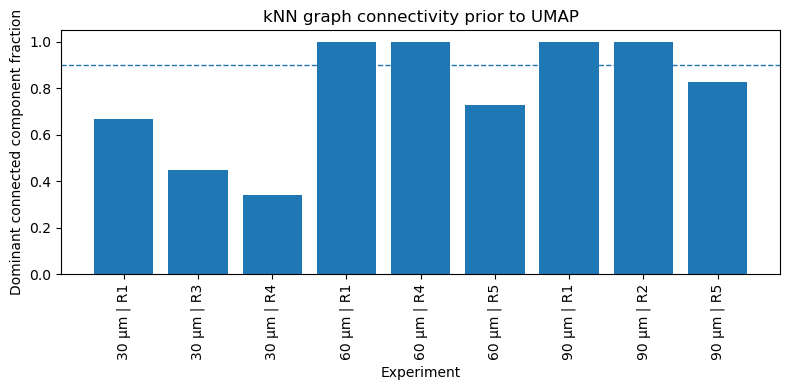

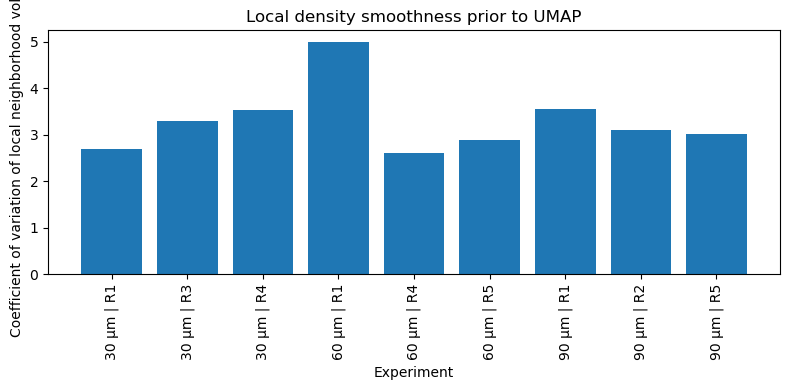

In [6]:
# ─── 6) UMAP ASSUMPTION CHECK + SUPPLEMENTARY FIGURE ─────────────────────────
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import connected_components
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def check_umap_assumptions(X, df, group_col="source_file", k=30):
    results = []

    for group, idx in df.groupby(group_col).groups.items():
        Xg = X.loc[idx].replace([np.inf, -np.inf], np.nan).dropna().values

        if Xg.shape[0] <= k:
            continue

        nbrs = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(Xg)
        distances, indices = nbrs.kneighbors(Xg)
        knn_graph = nbrs.kneighbors_graph(Xg, mode="connectivity")

        n_components, labels = connected_components(knn_graph, directed=False)
        component_sizes = np.bincount(labels)
        dominant_fraction = component_sizes.max() / Xg.shape[0]

        volumes = []
        for neigh_idx in indices:
            pts = Xg[neigh_idx]
            cov = np.cov(pts, rowvar=False) + np.eye(pts.shape[1]) * 1e-12
            eigvals = np.linalg.eigvalsh(cov)
            volume = np.sqrt(np.prod(np.clip(eigvals, 1e-12, None)))
            volumes.append(volume)

        volumes = np.array(volumes)

        size, rep = parse_tokens_from_name(group)

        results.append({
            group_col: group,
            "__size": size,
            "__rep": rep,
            "n_points": Xg.shape[0],
            "n_components": n_components,
            "dominant_component_fraction": dominant_fraction,
            "volume_cv": np.std(volumes) / np.mean(volumes)
        })

    return pd.DataFrame(results)


qc_results = check_umap_assumptions(
    X=X,
    df=df,
    group_col="source_file",
    k=UMAP_PARAMS["n_neighbors"]
)

size_order = {"30": 0, "60": 1, "90": 2}

qc_plot = qc_results.copy()
qc_plot["__size_order"] = qc_plot["__size"].map(size_order)

qc_plot = qc_plot.sort_values(
    ["__size_order", "__rep", "source_file"]
)

qc_plot["label"] = (
    qc_plot["__size"].astype(str) + " µm | " +
    qc_plot["__rep"].astype(str)
)

display(qc_plot)


# ─── Figure 1: Dominant connected component fraction ────────────────────────
plt.figure(figsize=(8, 4))

plt.bar(
    qc_plot["label"],
    qc_plot["dominant_component_fraction"]
)

plt.axhline(0.90, linestyle="--", linewidth=1)

plt.ylabel("Dominant connected component fraction")
plt.xlabel("Experiment")
plt.ylim(0, 1.05)
plt.xticks(rotation=90)
plt.title("kNN graph connectivity prior to UMAP")

plt.tight_layout()
plt.savefig(os.path.join(ASSET_DIR, "MACRO_supp_umap_knn_connectivity.png"), dpi=600, bbox_inches="tight", transparent=True)
plt.savefig(os.path.join(ASSET_DIR, "MACRO_supp_umap_knn_connectivity.pdf"), bbox_inches="tight", transparent=True)
plt.show()


# ─── Figure 2: Local density smoothness ─────────────────────────────────────
plt.figure(figsize=(8, 4))

plt.bar(
    qc_plot["label"],
    qc_plot["volume_cv"]
)

plt.ylabel("Coefficient of variation of local neighborhood volume")
plt.xlabel("Experiment")
plt.xticks(rotation=90)
plt.title("Local density smoothness prior to UMAP")

plt.tight_layout()
# plt.savefig(os.path.join(ASSET_DIR, "MACRO_supp_umap_density_smoothness.png"), dpi=600, bbox_inches="tight", transparent=True)
# plt.savefig(os.path.join(ASSET_DIR, "MACRO_supp_umap_density_smoothness.pdf"), bbox_inches="tight", transparent=True)
plt.show()

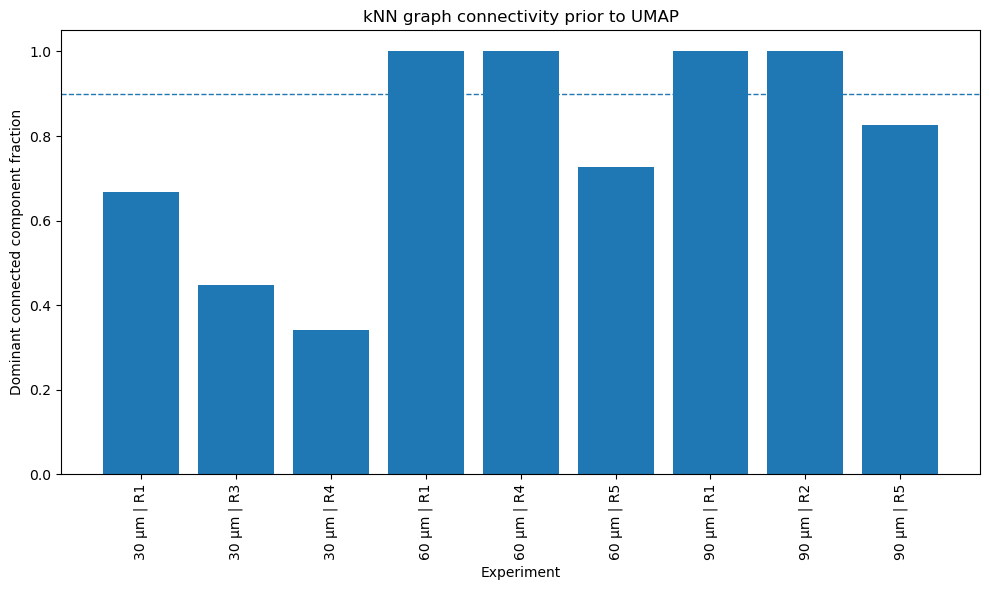

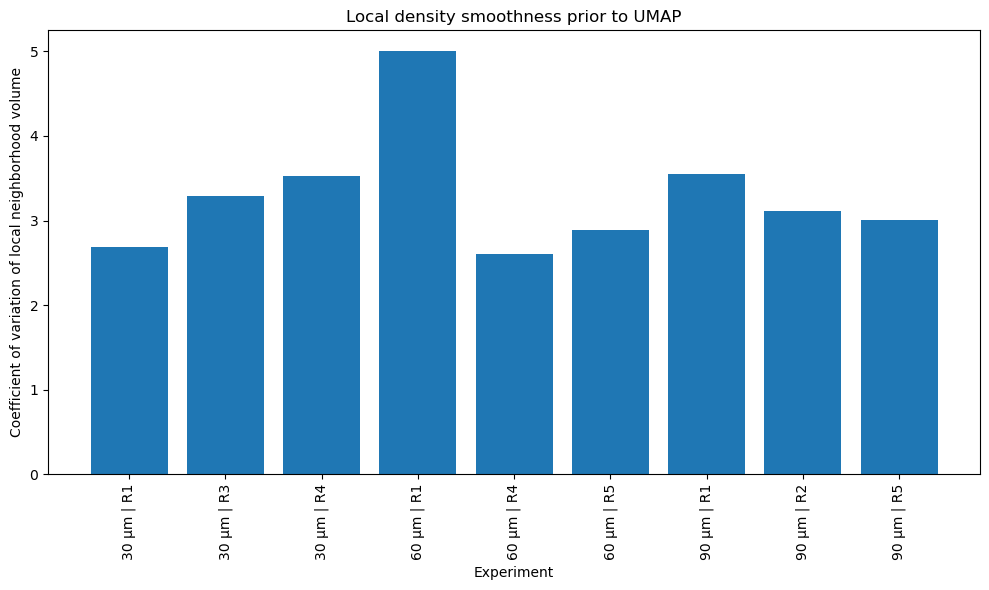

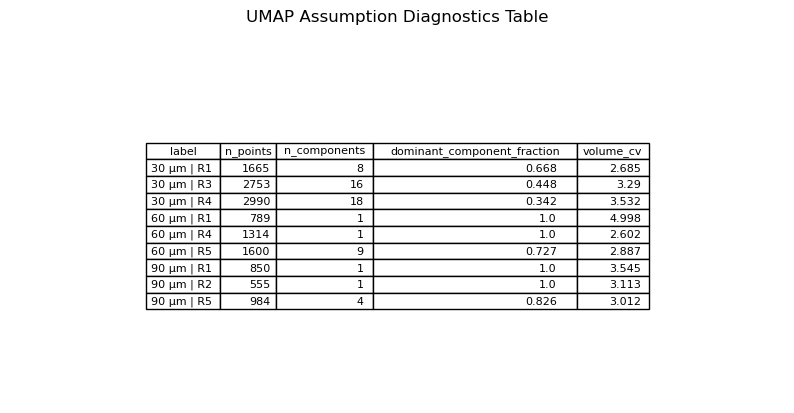

,source_file,__size,__rep,n_points,n_components,dominant_component_fraction,volume_cv,__size_order,label,passes_connectivity,passes_density_smoothness,suitable_for_umap
3,20240918_30um_M0_R1_tracks.csv,30,R1,1665,8,0.667868,2.685125,0,30 µm | R1,False,False,False
5,20241002_30um_M0_R3_tracks.csv,30,R3,2753,16,0.447512,3.290047,0,30 µm | R3,False,False,False
6,20250618_30um_M0_R4_tracks.csv,30,R4,2990,18,0.342475,3.531630,0,30 µm | R4,False,False,False
1,20240703_60um_M0_R1_tracks.csv,60,R1,789,1,1.000000,4.997731,1,60 µm | R1,True,False,False
0,20240508_60um_M0_R4_tracks.csv,60,R4,1314,1,1.000000,2.601604,1,60 µm | R4,True,False,False
8,20250627_60um_M0_R5_tracks.csv,60,R5,1600,9,0.726875,2.887239,1,60 µm | R5,False,False,False
2,20240911_90um_M0_R1_tracks.csv,90,R1,850,1,1.000000,3.545252,2,90 µm | R1,True,False,False
4,20240924_90um_M0_R2_tracks.csv,90,R2,555,1,1.000000,3.113073,2,90 µm | R2,True,False,False
7,20250624_90um_M0_R5_tracks.csv,90,R5,984,4,0.826220,3.011540,2,90 µm | R5,False,False,False


In [7]:
# ─── SUPPLEMENTARY FIGURES + TABLE EXPORT ────────────────────────────────────
import os
import matplotlib.pyplot as plt
import numpy as np

# --- ORDERING ---
size_order = {"30": 0, "60": 1, "90": 2}

qc_plot = qc_results.copy()

# Re-parse filename as size + replicate only
qc_plot["__size"], qc_plot["__rep"] = zip(
    *qc_plot["source_file"].apply(parse_tokens_from_name)
)

qc_plot["__size_order"] = qc_plot["__size"].map(size_order)

qc_plot = qc_plot.sort_values(
    ["__size_order", "__rep", "source_file"]
)

qc_plot["label"] = (
    qc_plot["__size"].astype(str) + " µm | " +
    qc_plot["__rep"].astype(str)
)

# ─── FIGURE 1: CONNECTIVITY ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

plt.bar(
    qc_plot["label"],
    qc_plot["dominant_component_fraction"]
)

plt.axhline(0.90, linestyle="--", linewidth=1)

plt.ylabel("Dominant connected component fraction")
plt.xlabel("Experiment")
plt.ylim(0, 1.05)
plt.xticks(rotation=90)
plt.title("kNN graph connectivity prior to UMAP")

plt.tight_layout()
plt.savefig(os.path.join(ASSET_DIR, "M0_supp_umap_knn_connectivity.png"), dpi=600, bbox_inches="tight", transparent=True)
plt.savefig(os.path.join(ASSET_DIR, "M0_supp_umap_knn_connectivity.pdf"), bbox_inches="tight", transparent=True)
plt.show()


# ─── FIGURE 2: DENSITY SMOOTHNESS ──────────────────────────────────────────
plt.figure(figsize=(10, 6))

plt.bar(
    qc_plot["label"],
    qc_plot["volume_cv"]
)

plt.ylabel("Coefficient of variation of local neighborhood volume")
plt.xlabel("Experiment")
plt.xticks(rotation=90)
plt.title("Local density smoothness prior to UMAP")

plt.tight_layout()
# plt.savefig(os.path.join(ASSET_DIR, "M0_supp_umap_density_smoothness.png"), dpi=600, bbox_inches="tight", transparent=True)
# plt.savefig(os.path.join(ASSET_DIR, "M0_supp_umap_density_smoothness.pdf"), bbox_inches="tight", transparent=True)
plt.show()


# ─── TABLE EXPORT CSV ──────────────────────────────────────────────────────
qc_plot.to_csv(
    os.path.join(ASSET_DIR, "M0_supp_umap_qc_table.csv"),
    index=False
)


# ─── TABLE AS FIGURE ───────────────────────────────────────────────────────
table_cols = [
    "label",
    "n_points",
    "n_components",
    "dominant_component_fraction",
    "volume_cv"
]

table_data = qc_plot[table_cols].copy()

table_data["dominant_component_fraction"] = table_data["dominant_component_fraction"].round(3)
table_data["volume_cv"] = table_data["volume_cv"].round(3)

fig, ax = plt.subplots(figsize=(10, len(table_data) * 0.4 + 1))
ax.axis("off")

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(col=list(range(len(table_data.columns))))

plt.title("UMAP Assumption Diagnostics Table", pad=20)

# plt.savefig(os.path.join(ASSET_DIR, "M0_supp_umap_qc_table.png"), dpi=600, bbox_inches="tight")
# plt.savefig(os.path.join(ASSET_DIR, "M0_supp_umap_qc_table.pdf"), bbox_inches="tight")
plt.show()


# ─── QC SUMMARY ────────────────────────────────────────────────────────────
qc_summary = qc_plot.copy()

qc_summary["passes_connectivity"] = qc_summary["dominant_component_fraction"] >= 0.90
qc_summary["passes_density_smoothness"] = qc_summary["volume_cv"] < 2.0

qc_summary["suitable_for_umap"] = (
    qc_summary["passes_connectivity"] &
    qc_summary["passes_density_smoothness"]
)

display(qc_summary)

In [8]:
# ─── 6) SCALE → UMAP → HDBSCAN — M0 MACROPHAGE ONLY ─────────────────────────

def _scale_umap_hdbscan(X_df, umap_params, hdb_params):
    """
    Input:
        X_df: pandas DataFrame, rows = tracks, cols = features

    Output:
        U: UMAP coordinates
        labels: HDBSCAN cluster labels, where -1 = noise
    """
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler.fit_transform(X_df.values)

    um = umap.UMAP(**umap_params)
    U = um.fit_transform(Xz)

    clusterer = hdbscan.HDBSCAN(**hdb_params)
    labels = clusterer.fit_predict(U)

    return U, labels, scaler, um, clusterer


# ─── Combined UMAP/HDBSCAN across all macrophage tracks ─────────────────────
X_all = X.replace([np.inf, -np.inf], np.nan).dropna()
idx_all = X_all.index

U_all, labels_all, scaler_all, umap_model, hdb_model = _scale_umap_hdbscan(
    X_all,
    UMAP_PARAMS,
    HDBSCAN_PARAMS
)

# Store results back into df
df.loc[idx_all, "UMAP1"] = U_all[:, 0]
df.loc[idx_all, "UMAP2"] = U_all[:, 1]
df.loc[idx_all, "cluster"] = labels_all

df["cluster"] = df["cluster"].astype("Int64")

# Embedding dataframe for plotting
df_emb = pd.DataFrame({
    "UMAP1": U_all[:, 0],
    "UMAP2": U_all[:, 1],
    "cluster": labels_all,
    "size_um": df.loc[idx_all, "__size"].astype(int).values,
    "condition": df.loc[idx_all, "condition"].values,
    "replicate": df.loc[idx_all, "__rep"].values,
    "source_file": df.loc[idx_all, "source_file"].values
}, index=idx_all)

print("M0 macrophage clusters including noise = -1:")
print(sorted(pd.unique(labels_all)))

print("\nCluster counts:")
print(df_emb["cluster"].value_counts().sort_index())

print("\nCluster counts by size:")
display(pd.crosstab(df_emb["size_um"], df_emb["cluster"]))

print("\nCluster counts by replicate:")
display(pd.crosstab(df_emb["replicate"], df_emb["cluster"]))

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



M0 macrophage clusters including noise = -1:
[np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]

Cluster counts:
cluster
-1     277
 0    3506
 1     878
 2    8839
Name: count, dtype: int64

Cluster counts by size:


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



cluster,-1,0,1,2
size_um,,,,
30,121,1286,332,5669
60,92,1380,412,1819
90,64,840,134,1351



Cluster counts by replicate:


cluster,-1,0,1,2
replicate,,,,
R1,57,845,534,1868
R2,17,168,48,322
R3,35,523,119,2076
R4,81,1004,152,3067
R5,87,966,25,1506


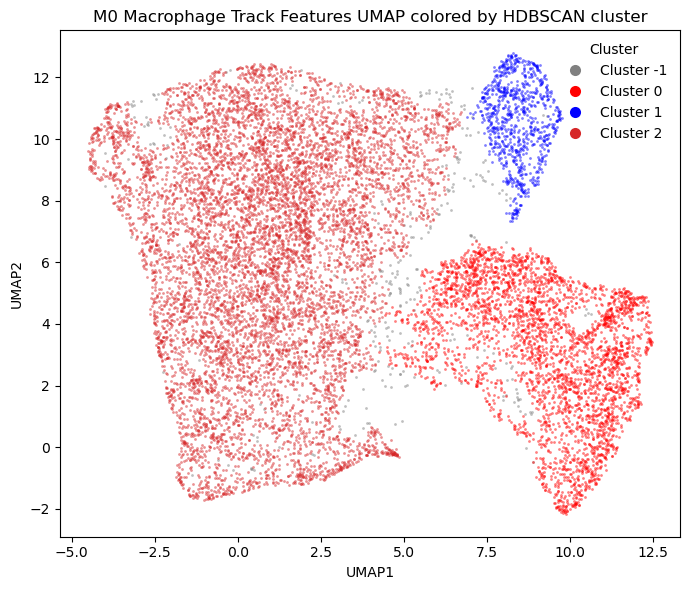

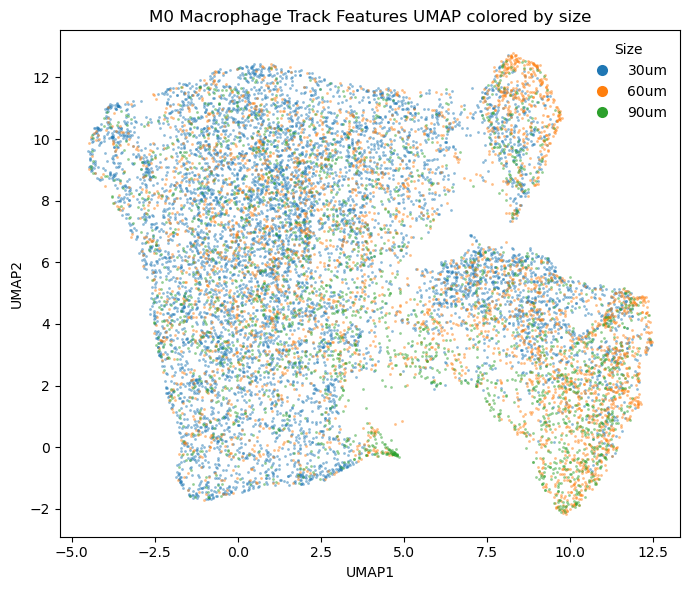

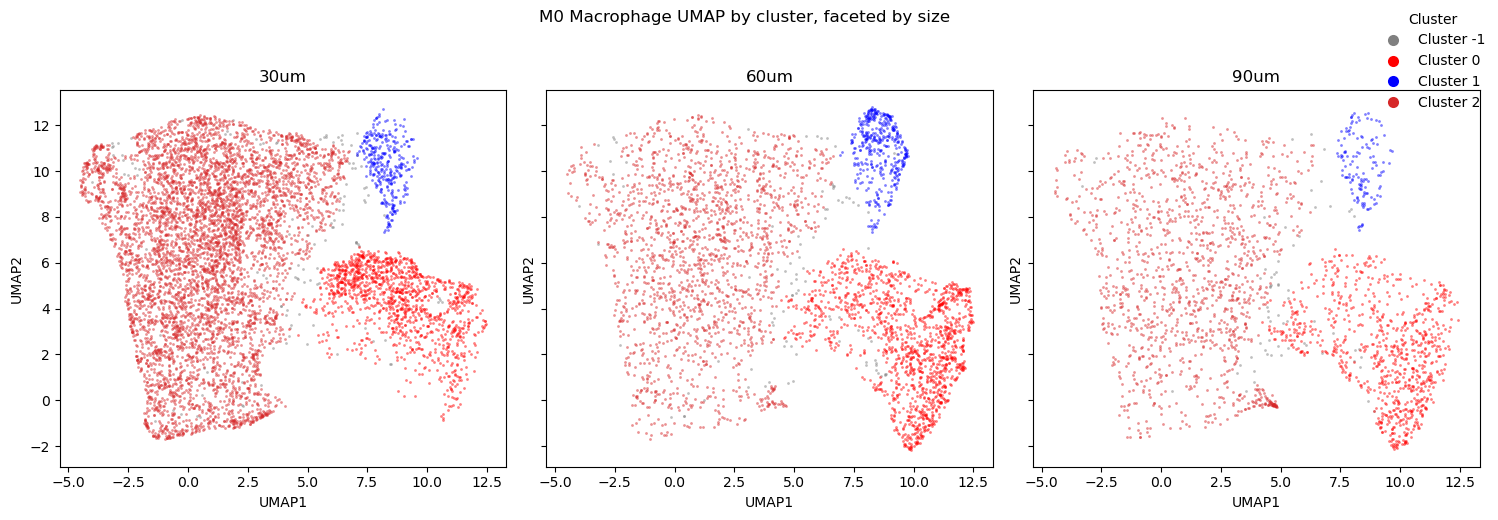

In [9]:
# ─── 7) SCATTERPLOTS (MATPLOTLIB) — M0 MACROPHAGE ONLY ──────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

POINT_SIZE = 4
POINT_ALPHA = 0.5

ASSET_DIR = "/Users/brianmah/Downloads"
os.makedirs(ASSET_DIR, exist_ok=True)

SAVE_KW = dict(
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02,
    transparent=True
)

# ── Fixed cluster color map ────────────────────────────────────────────────
CLUSTER_COLORS = {
    "0": "red",
    "1": "blue",
    "-1": "grey"   # HDBSCAN noise
}

FALLBACK_CMAP = plt.get_cmap("tab10")

clusters = df_emb["cluster"].astype(str)
cluster_labels = np.sort(clusters.unique())

def get_cluster_color(label, i):
    return CLUSTER_COLORS.get(label, FALLBACK_CMAP(i % FALLBACK_CMAP.N))


# ── Legend handles for clusters ────────────────────────────────────────────
cluster_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=get_cluster_color(lab, i),
        markeredgewidth=0,
        markersize=8,
        alpha=1.0,
        label=f"Cluster {lab}"
    )
    for i, lab in enumerate(cluster_labels)
]


# ── UMAP colored by cluster ─────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 6))

for i, lab in enumerate(cluster_labels):
    m = (clusters == lab).to_numpy()

    ax1.scatter(
        df_emb.loc[m, "UMAP1"],
        df_emb.loc[m, "UMAP2"],
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        c=[get_cluster_color(lab, i)],
        linewidths=0
    )

ax1.legend(handles=cluster_handles, title="Cluster", loc="upper right", frameon=False)
ax1.set_title("M0 Macrophage Track Features UMAP colored by HDBSCAN cluster")
ax1.set_xlabel("UMAP1")
ax1.set_ylabel("UMAP2")
fig1.tight_layout()

# fig1.savefig(os.path.join(ASSET_DIR, "M0_umap_cluster.png"), **SAVE_KW)
# fig1.savefig(os.path.join(ASSET_DIR, "M0_umap_cluster.pdf"), **SAVE_KW)
plt.show()


# ── UMAP colored by size ────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 6))

sizes = df_emb["condition"].astype(str)
size_labels = sorted(sizes.unique(), key=condition_sort_key)

SIZE_CMAP = plt.get_cmap("tab10")
size_color = {
    lab: SIZE_CMAP(i % SIZE_CMAP.N)
    for i, lab in enumerate(size_labels)
}

for lab in size_labels:
    m = (sizes == lab).to_numpy()

    ax2.scatter(
        df_emb.loc[m, "UMAP1"],
        df_emb.loc[m, "UMAP2"],
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        c=[size_color[lab]],
        linewidths=0
    )

size_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=size_color[lab],
        markeredgewidth=0,
        markersize=8,
        alpha=1.0,
        label=str(lab)
    )
    for lab in size_labels
]

ax2.legend(handles=size_handles, title="Size", loc="upper right", frameon=False)
ax2.set_title("M0 Macrophage Track Features UMAP colored by size")
ax2.set_xlabel("UMAP1")
ax2.set_ylabel("UMAP2")
fig2.tight_layout()

# fig2.savefig(os.path.join(ASSET_DIR, "M0_umap_size.png"), **SAVE_KW)
# fig2.savefig(os.path.join(ASSET_DIR, "M0_umap_size.pdf"), **SAVE_KW)
plt.show()


# ── Faceted UMAP by size, colored by cluster ────────────────────────────────
desired_sizes = ["30um", "60um", "90um"]

fig3, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for idx, size in enumerate(desired_sizes):
    ax = axes[idx]

    msize = (sizes == size).to_numpy()

    if not np.any(msize):
        ax.axis("off")
        continue

    for i, lab in enumerate(cluster_labels):
        m = msize & (clusters == lab).to_numpy()

        if not np.any(m):
            continue

        ax.scatter(
            df_emb.loc[m, "UMAP1"],
            df_emb.loc[m, "UMAP2"],
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            c=[get_cluster_color(lab, i)],
            linewidths=0
        )

    ax.set_title(size)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

fig3.legend(
    handles=cluster_handles,
    title="Cluster",
    loc="upper right",
    frameon=False
)

fig3.suptitle("M0 Macrophage UMAP by cluster, faceted by size", y=1.03)
fig3.tight_layout()

# fig3.savefig(os.path.join(ASSET_DIR, "M0_umap_faceted_size.png"), **SAVE_KW)
# fig3.savefig(os.path.join(ASSET_DIR, "M0_umap_faceted_size.pdf"), **SAVE_KW)
plt.show()

In [9]:
# ── SAVE INDIVIDUAL FACETED UMAPS — ONE PER SIZE ────────────────────────────

desired_sizes = ["30um", "60um", "90um"]

for size in desired_sizes:
    msize = (sizes == size).to_numpy()

    if not np.any(msize):
        continue

    fig, ax = plt.subplots(figsize=(7, 6))

    for i, lab in enumerate(cluster_labels):
        m = msize & (clusters == lab).to_numpy()

        if not np.any(m):
            continue

        ax.scatter(
            df_emb.loc[m, "UMAP1"],
            df_emb.loc[m, "UMAP2"],
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            c=[get_cluster_color(lab, i)],
            linewidths=0
        )

    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor=get_cluster_color(lab, i),
            markeredgewidth=0,
            markersize=8,
            alpha=1.0,
            label=f"Cluster {lab}"
        )
        for i, lab in enumerate(cluster_labels)
    ]

    ax.legend(handles=handles, title="Cluster", loc="upper right", frameon=False)

    ax.set_title(f"M0 Macrophage UMAP - {size}")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

    fig.tight_layout()

    safe_size = size.replace("um", "um")

    fig.savefig(os.path.join(ASSET_DIR, f"M0_umap_{safe_size}.png"), **SAVE_KW)
    fig.savefig(os.path.join(ASSET_DIR, f"M0_umap_{safe_size}.pdf"), **SAVE_KW)

    plt.close(fig)


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



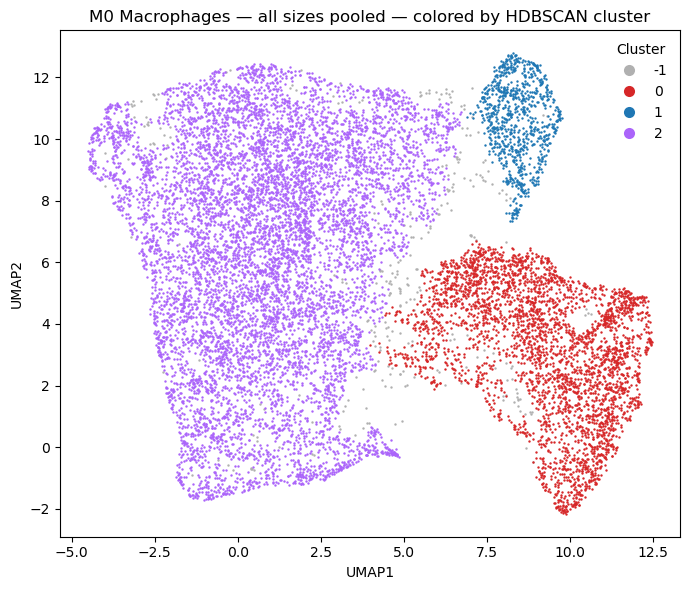

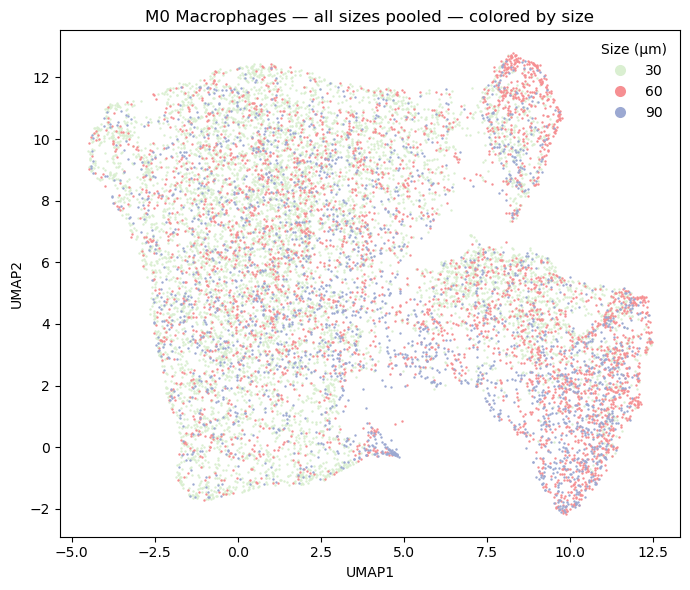

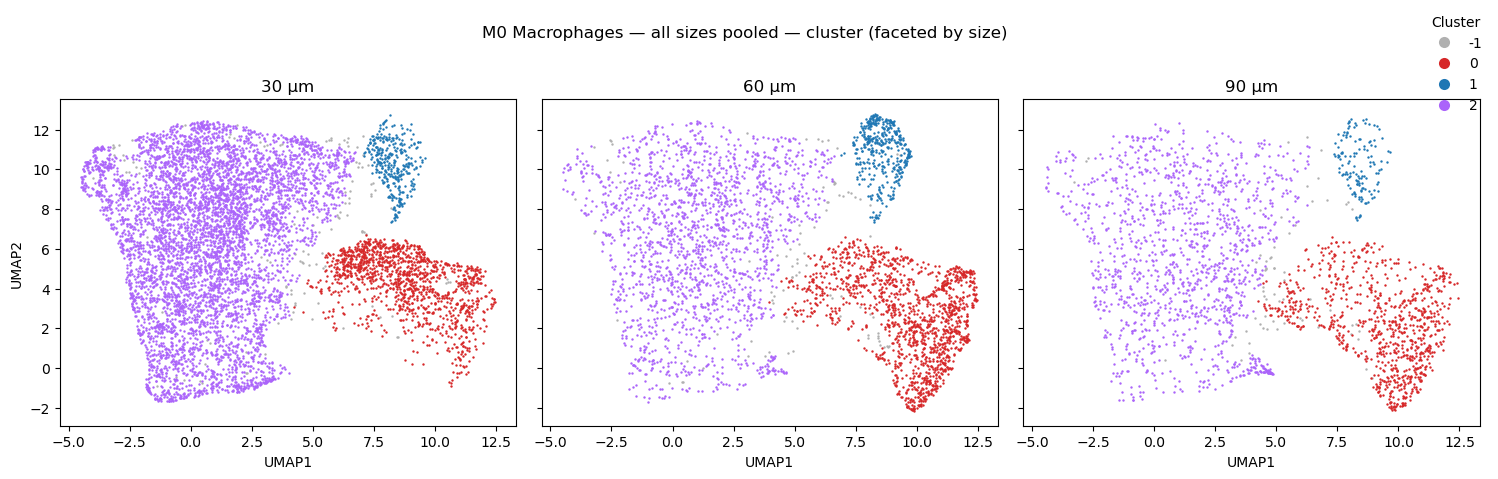

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
import umap
import hdbscan
import matplotlib.colors as mcolors

def with_alpha(color, alpha):
    r, g, b, _ = mcolors.to_rgba(color)
    return (r, g, b, alpha)

# --- styling ---
POINT_SIZE = 3
POINT_ALPHA = 1

SAVE_KW = dict(
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02,
    transparent=True
)

def _sanitize(s: str) -> str:
    return (
        str(s)
        .replace(" ", "_")
        .replace("|", "-")
        .replace("/", "-")
        .replace("\\", "-")
        .replace("(", "")
        .replace(")", "")
    )

# --- size colors ---
SIZE_COLOR_MAP = {
    "30": "#DAEFD1",
    "60": "#F68F92",
    "90": "#9CA9D2"
}

# --- cluster colors ---
CLUSTER_COLOR_MAP = {
    "-1": "#B0B0B0",
    "0": "#d62728",
    "1": "#1f77b4",
    "2": "#ab64fa"
}

FALLBACK_CMAP = plt.get_cmap("tab10")

def _cluster_color(label: str, i: int):
    return CLUSTER_COLOR_MAP.get(label, FALLBACK_CMAP(i % FALLBACK_CMAP.N))


def run_umap_hdbscan_matplotlib(df_sub, title_prefix):

    # --------------------------
    # Guard
    # --------------------------
    if df_sub.shape[0] < 5:
        return None

    X = (
        df_sub[feat_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if X.shape[0] < 5:
        return None

    dsub = df_sub.loc[X.index].copy()

    # --------------------------
    # Scale → UMAP → HDBSCAN
    # --------------------------
    Xz = StandardScaler().fit_transform(X.values)

    U = umap.UMAP(**UMAP_PARAMS).fit_transform(Xz)

    lab = hdbscan.HDBSCAN(**HDBSCAN_PARAMS).fit_predict(U)

    # --------------------------
    # Embedding dataframe
    # --------------------------
    df_emb_sub = pd.DataFrame({
        "UMAP1": U[:, 0],
        "UMAP2": U[:, 1],
        "cluster": lab,
        "condition": dsub["condition"].values,
        "size": dsub["__size"].astype(str).values,
        "replicate": dsub["__rep"].values,
        "source_file": dsub["source_file"].values,
    })

    prefix = _sanitize(title_prefix)

    clusters = df_emb_sub["cluster"].astype(str)
    cluster_labels = np.sort(clusters.unique())

    # ============================================================
    # PLOT A — COLORED BY CLUSTER
    # ============================================================
    fig, ax = plt.subplots(figsize=(7, 6))

    for i, cl in enumerate(cluster_labels):

        m = (clusters == cl).to_numpy()

        ax.scatter(
            df_emb_sub.loc[m, "UMAP1"],
            df_emb_sub.loc[m, "UMAP2"],
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            c=[_cluster_color(cl, i)],
            linewidths=0
        )

    cluster_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor=_cluster_color(cl, i),
            markeredgewidth=0,
            markersize=8,
            alpha=1.0,
            label=str(cl)
        )
        for i, cl in enumerate(cluster_labels)
    ]

    ax.legend(
        handles=cluster_handles,
        title="Cluster",
        frameon=False,
        loc="upper right"
    )

    ax.set_title(f"{title_prefix} — colored by HDBSCAN cluster")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

    fig.tight_layout()

    fig.savefig(os.path.join(ASSET_DIR, f"{prefix}__cluster.png"), **SAVE_KW)
    fig.savefig(os.path.join(ASSET_DIR, f"{prefix}__cluster.pdf"), **SAVE_KW)

    plt.show()

    # ============================================================
    # PLOT B — COLORED BY SIZE
    # ============================================================
    fig, ax = plt.subplots(figsize=(7, 6))

    size_order = ["30", "60", "90"]

    sizes_present = [
        s for s in size_order
        if s in set(df_emb_sub["size"].unique())
    ]

    for s in sizes_present:

        m = (df_emb_sub["size"] == s).to_numpy()

        ax.scatter(
            df_emb_sub.loc[m, "UMAP1"],
            df_emb_sub.loc[m, "UMAP2"],
            s=POINT_SIZE,
            c=[with_alpha(SIZE_COLOR_MAP[s], POINT_ALPHA)],
            linewidths=0
        )

    size_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor=SIZE_COLOR_MAP[s],
            markeredgewidth=0,
            markersize=8,
            alpha=1.0,
            label=f"{s}"
        )
        for s in sizes_present
    ]

    ax.legend(
        handles=size_handles,
        title="Size (μm)",
        frameon=False,
        loc="upper right"
    )

    ax.set_title(f"{title_prefix} — colored by size")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

    fig.tight_layout()

    fig.savefig(os.path.join(ASSET_DIR, f"{prefix}__size.png"), **SAVE_KW)
    fig.savefig(os.path.join(ASSET_DIR, f"{prefix}__size.pdf"), **SAVE_KW)

    plt.show()

    # ============================================================
    # PLOT C — FACETED BY SIZE
    # ============================================================
    n = len(sizes_present)

    if n > 0:

        fig, axes = plt.subplots(
            nrows=1,
            ncols=n,
            figsize=(5 * n, 4.5),
            sharex=True,
            sharey=True
        )

        if n == 1:
            axes = [axes]

        for col_idx, s in enumerate(sizes_present):

            ax = axes[col_idx]

            ms = (df_emb_sub["size"] == s).to_numpy()

            for i, cl in enumerate(cluster_labels):

                m = ms & (clusters == cl).to_numpy()

                if not np.any(m):
                    continue

                ax.scatter(
                    df_emb_sub.loc[m, "UMAP1"],
                    df_emb_sub.loc[m, "UMAP2"],
                    s=POINT_SIZE,
                    alpha=POINT_ALPHA,
                    c=[_cluster_color(cl, i)],
                    linewidths=0
                )

            ax.set_title(f"{s} µm")
            ax.set_xlabel("UMAP1")

            if col_idx == 0:
                ax.set_ylabel("UMAP2")

        fig.legend(
            handles=cluster_handles,
            title="Cluster",
            frameon=False,
            loc="upper right",
            bbox_to_anchor=(1, 1.07)
        )

        fig.suptitle(
            f"{title_prefix} — cluster (faceted by size)",
            y=1.02
        )

        fig.tight_layout()

        fig.savefig(os.path.join(ASSET_DIR, f"{prefix}__facet_size.png"), **SAVE_KW)
        fig.savefig(os.path.join(ASSET_DIR, f"{prefix}__facet_size.pdf"), **SAVE_KW)

        plt.show()

    return df_emb_sub


# ============================================================
# RUN POOLED M0 MACROPHAGE ANALYSIS
# ============================================================

df_M0 = df.copy()

_ = run_umap_hdbscan_matplotlib(
    df_M0,
    "M0 Macrophages — all sizes pooled"
)

cluster_str,-1,0,1,2
size_um,,,,
30,121,1286,332,5669
60,92,1380,412,1819
90,64,840,134,1351


cluster_str,0,1,2,-1
size_um,,,,
30,0.173596,0.044816,0.765254,0.016334
60,0.372671,0.111261,0.491223,0.024845
90,0.351612,0.056090,0.565509,0.026789


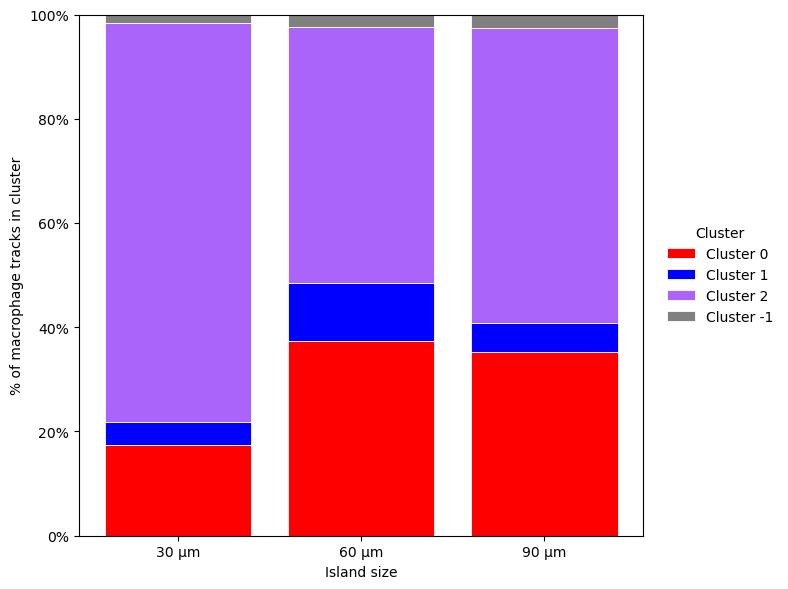


Chi-square test: cluster distribution differs by size
chi2 = 975.0683
p = 2.2049e-207
dof = 6

Observed counts:


cluster_str,-1,0,1,2
size_um,,,,
30,121,1286,332,5669
60,92,1380,412,1819
90,64,840,134,1351



Expected counts:


cluster_str,-1,0,1,2
size_um,,,,
30,152.001185,1923.885037,481.794370,4850.319407
60,75.980074,961.682815,240.832148,2424.504963
90,49.018741,620.432148,155.373481,1564.175630


In [13]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import plotly.express as px
from matplotlib.ticker import PercentFormatter

# ----------------------------
# 0) Cluster color mapping
# ----------------------------
cluster_labels = sorted(df_emb["cluster"].astype(str).unique())
plotly_palette = px.colors.qualitative.Plotly

CLUSTER_COLORS = {
    cl: plotly_palette[i % len(plotly_palette)]
    for i, cl in enumerate(cluster_labels)
}

# Force preferred cluster colors
CLUSTER_COLORS.update({
    "-1": "grey",
    "0": "red",
    "1": "blue",
    "2": "#ab64fa"
})

DEFAULT_COLOR = "grey"

# ----------------------------
# 1) Prep columns
# ----------------------------
df_plot = df_emb.copy()

if "size_um" not in df_plot.columns:
    df_plot["size_um"] = (
        df_plot["condition"]
        .astype(str)
        .str.extract(r"(\d+)\s*um", expand=False)
        .astype(int)
    )

df_plot["cluster_str"] = df_plot["cluster"].astype(str)

sizes = sorted(df_plot["size_um"].unique())

# ----------------------------
# 2) Compute fractions per size × cluster
# ----------------------------
counts = pd.crosstab(
    df_plot["size_um"],
    df_plot["cluster_str"]
)

props = counts.div(counts.sum(axis=1), axis=0).fillna(0)

cluster_order = list(props.columns)

# Put noise last
if "-1" in cluster_order:
    cluster_order = [c for c in cluster_order if c != "-1"] + ["-1"]

props = props[cluster_order]

display(counts)
display(props)

# ----------------------------
# 3) Plot: stacked bars by size
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(sizes))
bottom = np.zeros(len(sizes))

for cl in cluster_order:
    vals = props.loc[sizes, cl].values
    color = CLUSTER_COLORS.get(cl, DEFAULT_COLOR)

    ax.bar(
        x,
        vals,
        bottom=bottom,
        label=f"Cluster {cl}",
        color=color,
        edgecolor="white",
        linewidth=0.6
    )

    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f"{s} µm" for s in sizes])

ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

ax.set_ylabel("% of macrophage tracks in cluster")
ax.set_xlabel("Island size")

ax.legend(
    title="Cluster",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Font embedding
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

SAVE_DIR = "/Users/brianmah/Downloads"
os.makedirs(SAVE_DIR, exist_ok=True)

fig.tight_layout()

fig.savefig(os.path.join(SAVE_DIR, "M0_cluster_composition_by_size.pdf"))
fig.savefig(os.path.join(SAVE_DIR, "M0_cluster_composition_by_size.png"), dpi=600)

plt.show()

# ----------------------------
# 4) Optional chi-square test across size
# ----------------------------
if counts.shape[0] >= 2 and counts.shape[1] >= 2:
    chi2, p, dof, expected = chi2_contingency(counts.values)

    print("\nChi-square test: cluster distribution differs by size")
    print(f"chi2 = {chi2:.4f}")
    print(f"p = {p:.4e}")
    print(f"dof = {dof}")

    expected_df = pd.DataFrame(
        expected,
        index=counts.index,
        columns=counts.columns
    )

    print("\nObserved counts:")
    display(counts)

    print("\nExpected counts:")
    display(expected_df)

else:
    print("[WARN] Not enough sizes/clusters for chi-square test.")


M0_macrophages_all_sizes_pooled
Rows after dropna: 13500
Non-noise: 13223
Noise: 277
Clusters non-noise: [np.int64(0), np.int64(1), np.int64(2)]
0    3506
1     878
2    8839
[CV] RF accuracy: 0.997 ± 0.001 (n_splits=5)


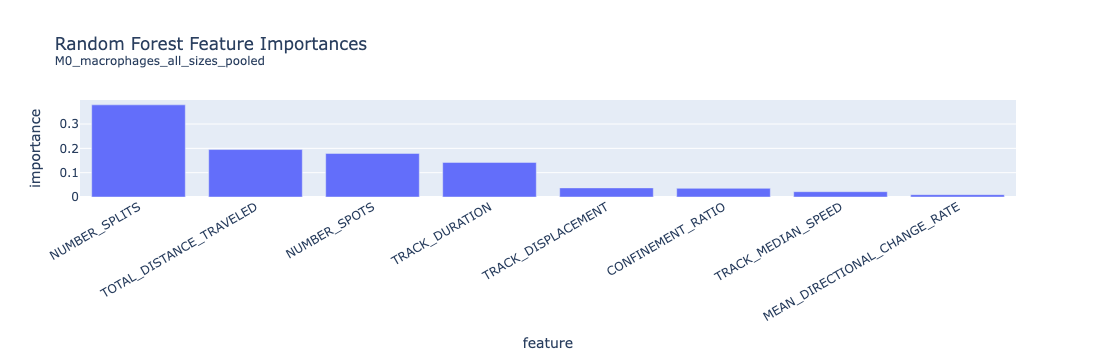

,feature,importance
0,NUMBER_SPLITS,0.378831
1,TOTAL_DISTANCE_TRAVELED,0.195119
2,NUMBER_SPOTS,0.179190
3,TRACK_DURATION,0.142344
4,TRACK_DISPLACEMENT,0.037511
5,CONFINEMENT_RATIO,0.035604
6,TRACK_MEDIAN_SPEED,0.021789
7,MEAN_DIRECTIONAL_CHANGE_RATE,0.009612


[INFO] Auto-expanded SHAP_XLIM for M0_macrophages_all_sizes_pooled: data range=(-0.665, 0.691) -> xlim=(-0.761, 0.761)

[SHAP] Global mean(|SHAP|) — M0_macrophages_all_sizes_pooled


,feature,mean_abs_SHAP
0,NUMBER_SPLITS,0.155007
1,NUMBER_SPOTS,0.067862
2,TOTAL_DISTANCE_TRAVELED,0.059260
3,TRACK_DURATION,0.055619
4,TRACK_DISPLACEMENT,0.014235
5,CONFINEMENT_RATIO,0.012409
6,TRACK_MEDIAN_SPEED,0.007062
7,MEAN_DIRECTIONAL_CHANGE_RATE,0.003749


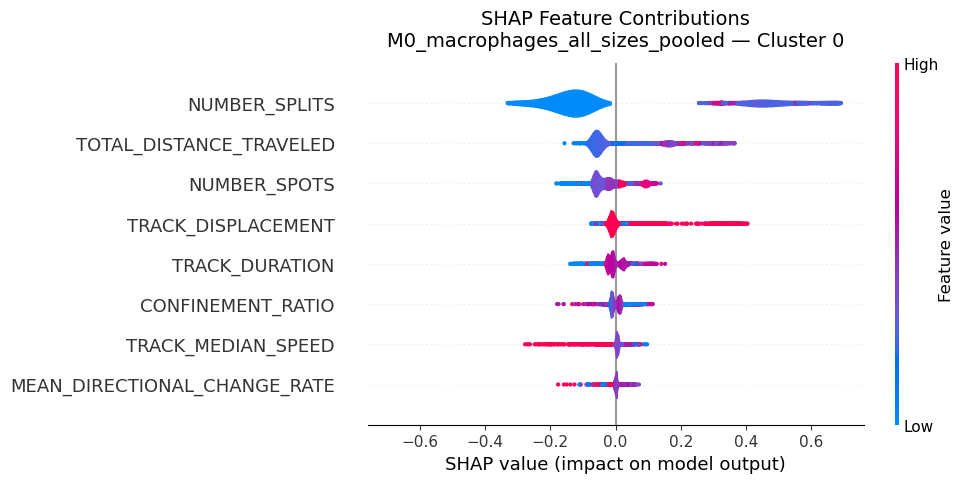


[SHAP] mean(|SHAP|) — M0_macrophages_all_sizes_pooled — Cluster 0


,feature,mean_abs_SHAP
0,NUMBER_SPLITS,0.232510
1,TOTAL_DISTANCE_TRAVELED,0.081426
2,NUMBER_SPOTS,0.047666
3,TRACK_DISPLACEMENT,0.021113
4,TRACK_DURATION,0.019283
5,CONFINEMENT_RATIO,0.013102
6,TRACK_MEDIAN_SPEED,0.006933
7,MEAN_DIRECTIONAL_CHANGE_RATE,0.004388


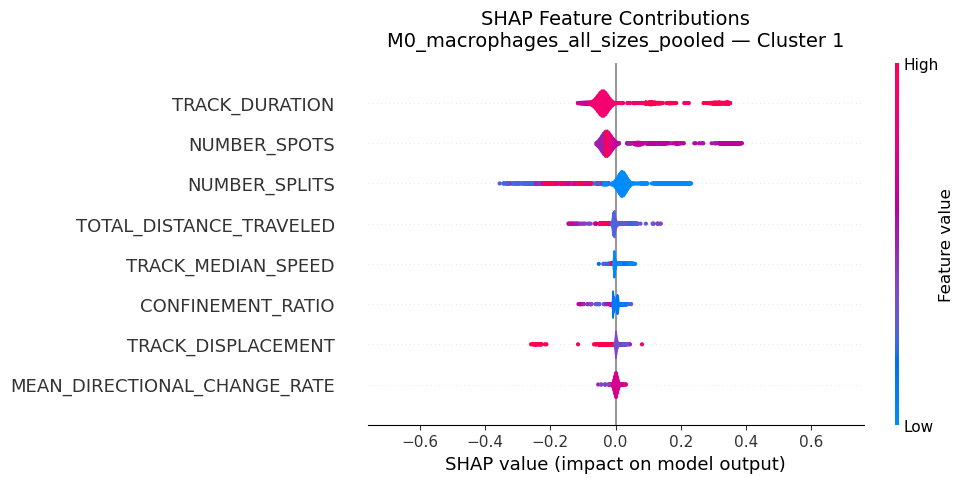


[SHAP] mean(|SHAP|) — M0_macrophages_all_sizes_pooled — Cluster 1


,feature,mean_abs_SHAP
0,TRACK_DURATION,0.069088
1,NUMBER_SPOTS,0.056776
2,NUMBER_SPLITS,0.056718
3,TOTAL_DISTANCE_TRAVELED,0.012258
4,TRACK_MEDIAN_SPEED,0.006203
5,CONFINEMENT_RATIO,0.006203
6,TRACK_DISPLACEMENT,0.003715
7,MEAN_DIRECTIONAL_CHANGE_RATE,0.001898


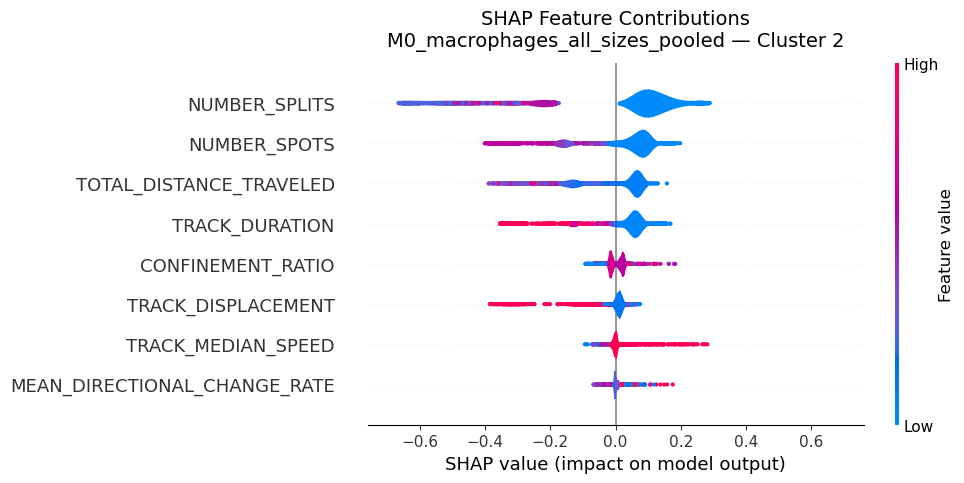


[SHAP] mean(|SHAP|) — M0_macrophages_all_sizes_pooled — Cluster 2


,feature,mean_abs_SHAP
0,NUMBER_SPLITS,0.175792
1,NUMBER_SPOTS,0.099145
2,TOTAL_DISTANCE_TRAVELED,0.084096
3,TRACK_DURATION,0.078485
4,CONFINEMENT_RATIO,0.017923
5,TRACK_DISPLACEMENT,0.017877
6,TRACK_MEDIAN_SPEED,0.008048
7,MEAN_DIRECTIONAL_CHANGE_RATE,0.004961



[ASSETS] Saved SHAP assets to: /Users/brianmah/Downloads/SHAP_assets_M0/M0_macrophages_all_sizes_pooled

Saved SHAP assets under: /Users/brianmah/Downloads/SHAP_assets_M0


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# RF + SHAP for M0 MACROPHAGE-ONLY DATA
# + consistent feature axis across SHAP violin plots
# + fixed SHAP value axis limits
# + export SHAP violins + SHAP tables as PNG/PDF/CSV
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from pathlib import Path
import re

import plotly.express as px
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# -------------------- ASSET OUTPUT --------------------
ASSET_DIR = Path("/Users/brianmah/Downloads/SHAP_assets_M0")
ASSET_DIR.mkdir(parents=True, exist_ok=True)

SAVEFIG_KW = dict(
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02,
    transparent=True
)

# -------------------- AXIS SETTINGS --------------------
SHAP_XLIM = (-0.5, 0.5)
AUTO_EXPAND_SHAP_XLIM = True
SHAP_PAD_FRAC = 0.10

def _safe(s: str) -> str:
    return re.sub(r"[^\w\-]+", "_", str(s)).strip("_")[:160]


def save_df_as_png(df: pd.DataFrame, filepath: Path, max_rows: int = 40, fontsize: int = 9):
    df_show = df.head(max_rows).copy()

    fig_h = max(2.0, 0.35 * len(df_show) + 1.2)
    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.axis("off")

    tbl = ax.table(
        cellText=df_show.values,
        colLabels=df_show.columns,
        cellLoc="center",
        loc="center"
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, 1.25)

    fig.tight_layout()
    fig.savefig(filepath, **SAVEFIG_KW)
    plt.close(fig)


def _coi_explanation_for_class(shap_values, coi_idx):
    if hasattr(shap_values, "values"):
        if shap_values.values.ndim == 3:
            return shap.Explanation(
                values=shap_values.values[:, :, coi_idx],
                base_values=np.array(shap_values.base_values)[:, coi_idx],
                data=shap_values.data,
                feature_names=shap_values.feature_names
            )
        else:
            return shap_values
    else:
        return shap_values[coi_idx]


def _global_feature_order_from_shap(shap_values, feat_names, max_display=20):
    if hasattr(shap_values, "values"):
        V = shap_values.values

        if V.ndim == 3:
            mean_abs = np.abs(V).mean(axis=0).mean(axis=1)
        else:
            mean_abs = np.abs(V).mean(axis=0)

    else:
        mean_abs = np.mean(
            [np.abs(v).mean(axis=0) for v in shap_values],
            axis=0
        )

    idx = np.argsort(mean_abs)[::-1][:max_display]
    return [feat_names[i] for i in idx]


def explain_clusters_shap_and_export(
    model,
    X_eval,
    y_clusters,
    feat_names=None,
    clusters_to_plot=None,
    max_display=20,
    run_tag="M0_macrophages",
    outdir: Path = ASSET_DIR
):
    if len(np.unique(y_clusters)) < 2:
        print("[WARN] <2 classes in y_clusters; SHAP per-class view not meaningful.")
        return None, None

    run_tag_safe = _safe(run_tag)

    outdir_run = outdir / run_tag_safe
    outdir_run.mkdir(parents=True, exist_ok=True)

    if hasattr(X_eval, "columns"):
        feat_names_local = list(X_eval.columns)
        X_for_shap = X_eval
        X_plot = X_eval.values
    else:
        if feat_names is None:
            feat_names_local = [f"feat_{i}" for i in range(X_eval.shape[1])]
        else:
            assert len(feat_names) == X_eval.shape[1]
            feat_names_local = list(feat_names)

        X_for_shap = pd.DataFrame(X_eval, columns=feat_names_local)
        X_plot = X_eval

    le = LabelEncoder()
    le.fit(y_clusters)

    raw_classes = sorted(np.unique(y_clusters))

    if clusters_to_plot is None:
        clusters_to_plot = raw_classes
    else:
        clusters_to_plot = [c for c in clusters_to_plot if c in raw_classes]

        if not clusters_to_plot:
            print("[WARN] None of the requested clusters exist in y_clusters.")
            return None, None

    explainer = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_for_shap)

    shared_feats = _global_feature_order_from_shap(
        shap_values,
        feat_names_local,
        max_display=max_display
    )

    feat_idx = [feat_names_local.index(f) for f in shared_feats]

    # Consistent SHAP x-limits
    run_xlim = list(SHAP_XLIM)

    if hasattr(shap_values, "values"):
        V = shap_values.values

        if V.ndim == 3:
            pooled = V[:, feat_idx, :].reshape(-1)
        else:
            pooled = V[:, feat_idx].reshape(-1)

    else:
        pooled = np.concatenate(
            [sv[:, feat_idx].reshape(-1) for sv in shap_values],
            axis=0
        )

    run_min = float(np.min(pooled))
    run_max = float(np.max(pooled))

    if AUTO_EXPAND_SHAP_XLIM and (run_min < run_xlim[0] or run_max > run_xlim[1]):
        m = max(abs(run_min), abs(run_max))
        pad = SHAP_PAD_FRAC * m
        run_xlim = [-m - pad, m + pad]

        print(
            f"[INFO] Auto-expanded SHAP_XLIM for {run_tag}: "
            f"data range=({run_min:.3g}, {run_max:.3g}) "
            f"-> xlim=({run_xlim[0]:.3g}, {run_xlim[1]:.3g})"
        )

    # Global importance
    if hasattr(shap_values, "values"):
        V = shap_values.values

        if V.ndim == 3:
            global_mean_abs = np.abs(V).mean(axis=0).mean(axis=1)
        else:
            global_mean_abs = np.abs(V).mean(axis=0)

    else:
        global_mean_abs = np.mean(
            [np.abs(v).mean(axis=0) for v in shap_values],
            axis=0
        )

    global_imp = (
        pd.DataFrame({
            "feature": feat_names_local,
            "mean_abs_SHAP": global_mean_abs
        })
        .sort_values("mean_abs_SHAP", ascending=False)
        .reset_index(drop=True)
    )

    global_imp_2col = global_imp.loc[
        global_imp["feature"].isin(shared_feats),
        ["feature", "mean_abs_SHAP"]
    ]

    global_imp_2col = (
        global_imp_2col
        .set_index("feature")
        .loc[shared_feats]
        .reset_index()
    )

    global_png = outdir_run / f"{run_tag_safe}__SHAP_global_mean_abs.png"
    global_csv = outdir_run / f"{run_tag_safe}__SHAP_global_mean_abs.csv"

    save_df_as_png(global_imp_2col, global_png, max_rows=max_display)
    global_imp_2col.to_csv(global_csv, index=False)

    print(f"\n[SHAP] Global mean(|SHAP|) — {run_tag}")
    display(global_imp_2col)

    tables_long = []

    for COI in clusters_to_plot:
        encoded_label = le.transform([COI])[0]
        coi_idx_arr = np.where(model.classes_ == encoded_label)[0]

        if len(coi_idx_arr) == 0:
            print(f"[WARN] Cluster {COI} not found in model.classes_; skipping.")
            continue

        coi_idx = coi_idx_arr[0]

        coi_shap = _coi_explanation_for_class(shap_values, coi_idx)
        vals = getattr(coi_shap, "values", coi_shap)

        if hasattr(coi_shap, "values"):
            vals_fixed = coi_shap.values[:, feat_idx]

            data_fixed = None
            if getattr(coi_shap, "data", None) is not None:
                data_fixed = np.asarray(coi_shap.data)[:, feat_idx]

            coi_shap_fixed = shap.Explanation(
                values=vals_fixed,
                base_values=coi_shap.base_values,
                data=data_fixed,
                feature_names=shared_feats
            )

        else:
            vals_fixed = vals[:, feat_idx]
            coi_shap_fixed = vals_fixed

        # SHAP violin
        plt.figure(figsize=(10, 6))

        try:
            shap.plots.violin(
                coi_shap_fixed,
                max_display=len(shared_feats),
                show=False
            )
        except Exception:
            shap.summary_plot(
                vals_fixed,
                X_plot[:, feat_idx],
                feature_names=shared_feats,
                plot_type="violin",
                max_display=len(shared_feats),
                show=False
            )

        plt.title(
            f"SHAP Feature Contributions\n{run_tag} — Cluster {COI}",
            fontsize=14,
            pad=12
        )

        plt.gca().set_xlim(run_xlim[0], run_xlim[1])

        fig = plt.gcf()

        out_png = outdir_run / f"{run_tag_safe}__cluster_{COI}__SHAP_violin.png"
        out_pdf = outdir_run / f"{run_tag_safe}__cluster_{COI}__SHAP_violin.pdf"

        fig.savefig(out_png, **SAVEFIG_KW)
        fig.savefig(out_pdf, **SAVEFIG_KW)

        plt.show()
        plt.close()

        # Per-cluster importance table
        mean_abs = np.abs(vals_fixed).mean(axis=0)

        df_imp2 = (
            pd.DataFrame({
                "feature": shared_feats,
                "mean_abs_SHAP": mean_abs
            })
            .sort_values("mean_abs_SHAP", ascending=False)
            .reset_index(drop=True)
        )

        print(f"\n[SHAP] mean(|SHAP|) — {run_tag} — Cluster {COI}")
        display(df_imp2)

        tbl_png = outdir_run / f"{run_tag_safe}__cluster_{COI}__SHAP_mean_abs_table.png"
        tbl_csv = outdir_run / f"{run_tag_safe}__cluster_{COI}__SHAP_mean_abs_table.csv"

        save_df_as_png(df_imp2, tbl_png, max_rows=max_display)
        df_imp2.to_csv(tbl_csv, index=False)

        df_long = df_imp2.copy()
        df_long.insert(0, "cluster", COI)
        tables_long.append(df_long)

    if tables_long:
        all_tbl_long = pd.concat(tables_long, ignore_index=True)

        all_png = outdir_run / f"{run_tag_safe}__SHAP_all_clusters_long.png"
        all_csv = outdir_run / f"{run_tag_safe}__SHAP_all_clusters_long.csv"

        save_df_as_png(all_tbl_long, all_png, max_rows=60)
        all_tbl_long.to_csv(all_csv, index=False)

        return all_tbl_long, global_imp_2col

    return None, global_imp_2col


def run_rf_shap_export(
    df_in: pd.DataFrame,
    cluster_col: str = "cluster",
    title: str = "M0_macrophages_all_sizes_pooled",
    outdir=ASSET_DIR
):
    d = df_in[df_in[cluster_col].notna()].copy()

    if len(d) == 0:
        print(f"[SKIP] {title}: no rows with {cluster_col}")
        return None, None, None, None

    X_df = (
        d[feat_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(X_df) < 10:
        print(f"[SKIP] {title}: too few rows after dropna, n={len(X_df)}")
        return None, None, None, None

    y = d.loc[X_df.index, cluster_col].astype(int).values

    # Remove HDBSCAN noise
    mask = y != -1

    X_keep_df = X_df.loc[X_df.index[mask]].copy()
    y_clust = y[mask]

    print("\n" + "=" * 100)
    print(title)
    print(f"Rows after dropna: {len(y)}")
    print(f"Non-noise: {len(y_clust)}")
    print(f"Noise: {len(y) - len(y_clust)}")
    print("Clusters non-noise:", sorted(pd.unique(y_clust)))
    print(pd.Series(y_clust).value_counts().sort_index().to_string())
    print("=" * 100)

    if len(np.unique(y_clust)) < 2:
        print("[WARN] <2 non-noise clusters; RF classification is not meaningful.")
        return None, None, None, None

    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz_keep = scaler.fit_transform(X_keep_df.values)

    rf = RandomForestClassifier(**RF_PARAMS)

    n_splits = (
        5
        if len(y_clust) >= 50 and all((y_clust == k).sum() >= 5 for k in np.unique(y_clust))
        else 3
    )

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        rf,
        Xz_keep,
        y_clust,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    print(f"[CV] RF accuracy: {scores.mean():.3f} ± {scores.std():.3f} (n_splits={n_splits})")

    rf.fit(Xz_keep, y_clust)

    fi = (
        pd.DataFrame({
            "feature": feat_cols,
            "importance": rf.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    fig_b = px.bar(
        fi,
        x="feature",
        y="importance",
        title=f"Random Forest Feature Importances<br><sup>{title}</sup>"
    )

    fig_b.update_layout(xaxis_tickangle=-30)
    fig_b.show()

    display(fi.head(25))

    shap_tbl_long, shap_global_imp_2col = explain_clusters_shap_and_export(
        model=rf,
        X_eval=Xz_keep,
        y_clusters=y_clust,
        feat_names=feat_cols,
        clusters_to_plot=None,
        max_display=20,
        run_tag=title,
        outdir=outdir
    )

    print(f"\n[ASSETS] Saved SHAP assets to: {(outdir / _safe(title)).resolve()}")

    return rf, fi, shap_tbl_long, shap_global_imp_2col


# ─── RUN M0 MACROPHAGE RF + SHAP EXPORT ─────────────────────────────────────
rf_m0, fi_m0, shap_m0_long, shap_m0_global = run_rf_shap_export(
    df_in=df,
    cluster_col="cluster",
    title="M0_macrophages_all_sizes_pooled"
)

print(f"\nSaved SHAP assets under: {ASSET_DIR.resolve()}")


M0_macrophages_all_sizes_pooled
Rows after dropna: 13500
Non-noise: 13223
Noise: 277
Clusters non-noise: [np.int64(0), np.int64(1), np.int64(2)]
0    3506
1     878
2    8839
[CV] RF accuracy: 0.997 ± 0.001 (n_splits=5)


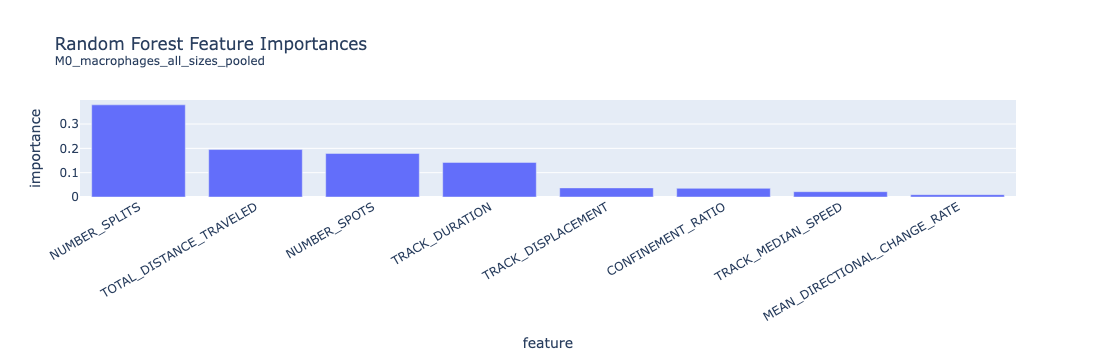

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.



Saved PNGs to: /Users/brianmah/Downloads/M0_SHAPPlots


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# RF + SHAP for M0 MACROPHAGE-ONLY DATA
# + PNG export + titles
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from pathlib import Path
import re

import plotly.express as px
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ---------- Output folder ----------
OUTDIR = Path("/Users/brianmah/Downloads/M0_SHAPPlots")
OUTDIR.mkdir(exist_ok=True, parents=True)

def _safe(s: str) -> str:
    return re.sub(r"[^\w\-]+", "_", str(s)).strip("_")[:160]


def save_df_as_png(df: pd.DataFrame, filepath: Path, max_rows: int = 25, fontsize: int = 10):
    df_show = df.head(max_rows).copy()

    fig_h = max(2.0, 0.35 * len(df_show) + 1.2)
    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.axis("off")

    tbl = ax.table(
        cellText=df_show.values,
        colLabels=df_show.columns,
        cellLoc="center",
        loc="center"
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, 1.25)

    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig)


def _coi_explanation_for_class(shap_values, coi_idx):
    if hasattr(shap_values, "values"):
        if shap_values.values.ndim == 3:
            return shap.Explanation(
                values=shap_values.values[:, :, coi_idx],
                base_values=np.array(shap_values.base_values)[:, coi_idx],
                data=shap_values.data,
                feature_names=shap_values.feature_names
            )
        else:
            return shap_values
    else:
        return shap_values[coi_idx]


def explain_clusters_shap_and_export(
    model,
    X_eval,
    y_clusters,
    feat_names=None,
    clusters_to_plot=None,
    max_display=20,
    outdir=OUTDIR,
    run_tag="M0_macrophages"
):
    if len(np.unique(y_clusters)) < 2:
        print("[WARN] <2 classes in y_clusters; SHAP per-class view not meaningful.")
        return None

    if hasattr(X_eval, "columns"):
        feat_names_local = list(X_eval.columns)
        X_for_shap = X_eval
        X_plot = X_eval.values
    else:
        if feat_names is None:
            feat_names_local = [f"feat_{i}" for i in range(X_eval.shape[1])]
        else:
            assert len(feat_names) == X_eval.shape[1], "feat_names length must match X_eval.shape[1]"
            feat_names_local = list(feat_names)

        X_for_shap = pd.DataFrame(X_eval, columns=feat_names_local)
        X_plot = X_eval

    le = LabelEncoder()
    le.fit(y_clusters)

    raw_classes = sorted(np.unique(y_clusters))

    if clusters_to_plot is None:
        clusters_to_plot = raw_classes
    else:
        clusters_to_plot = [c for c in clusters_to_plot if c in raw_classes]

        if not clusters_to_plot:
            print("[WARN] None of the requested clusters exist in y_clusters.")
            return None

    outdir.mkdir(exist_ok=True, parents=True)
    run_tag = _safe(run_tag)

    explainer = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_for_shap)

    tables = []

    for COI in clusters_to_plot:
        encoded_label = le.transform([COI])[0]
        coi_idx_arr = np.where(model.classes_ == encoded_label)[0]

        if len(coi_idx_arr) == 0:
            print(f"[WARN] Cluster {COI} not found in model.classes_; skipping.")
            continue

        coi_idx = coi_idx_arr[0]

        coi_shap = _coi_explanation_for_class(shap_values, coi_idx)
        vals = getattr(coi_shap, "values", coi_shap)

        # SHAP violin plot
        plt.figure(figsize=(10, 6))

        try:
            shap.plots.violin(
                coi_shap,
                max_display=max_display,
                show=False
            )
        except Exception:
            shap.summary_plot(
                vals,
                X_plot,
                feature_names=feat_names_local,
                plot_type="violin",
                max_display=max_display,
                show=False
            )

        plt.title(
            f"SHAP Feature Contributions\n{run_tag} — Cluster {COI}",
            fontsize=14,
            pad=12
        )

        plt.savefig(
            outdir / f"{run_tag}_cluster_{COI}_SHAP_violin.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.close()

        # mean|SHAP| table
        mean_abs = np.abs(vals).mean(axis=0)

        df_imp = (
            pd.DataFrame({
                "feature": feat_names_local,
                "mean_abs_SHAP": mean_abs
            })
            .sort_values("mean_abs_SHAP", ascending=False)
            .reset_index(drop=True)
        )

        df_imp.insert(0, "cluster", COI)
        tables.append(df_imp)

        save_df_as_png(
            df_imp,
            outdir / f"{run_tag}_cluster_{COI}_SHAP_table.png",
            max_rows=max_display
        )

    if tables:
        all_tbl = pd.concat(tables, ignore_index=True)

        save_df_as_png(
            all_tbl,
            outdir / f"{run_tag}_SHAP_all_clusters_table.png",
            max_rows=40
        )

        return all_tbl

    return None


def run_rf_shap_export(
    df_in: pd.DataFrame,
    cluster_col: str = "cluster",
    title: str = "M0_macrophages",
    outdir=OUTDIR
):
    title_safe = _safe(title)
    outdir.mkdir(exist_ok=True, parents=True)

    d = df_in[df_in[cluster_col].notna()].copy()

    if len(d) == 0:
        print(f"[SKIP] {title}: no rows with {cluster_col}")
        return None, None, None

    X_df = (
        d[feat_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(X_df) < 10:
        print(f"[SKIP] {title}: too few rows after dropna, n={len(X_df)}")
        return None, None, None

    y = d.loc[X_df.index, cluster_col].astype(int).values

    # Remove HDBSCAN noise
    mask = y != -1

    X_keep_df = X_df.loc[X_df.index[mask]].copy()
    y_clust = y[mask]

    print("\n" + "=" * 100)
    print(title)
    print(f"Rows after dropna: {len(y)}")
    print(f"Non-noise: {len(y_clust)}")
    print(f"Noise: {len(y) - len(y_clust)}")
    print("Clusters non-noise:", sorted(pd.unique(y_clust)))
    print(pd.Series(y_clust).value_counts().sort_index().to_string())
    print("=" * 100)

    if len(np.unique(y_clust)) < 2:
        print("[WARN] <2 non-noise clusters; RF classification is not meaningful.")
        return None, None, None

    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz_keep = scaler.fit_transform(X_keep_df.values)

    rf = RandomForestClassifier(**RF_PARAMS)

    n_splits = (
        5
        if len(y_clust) >= 50 and all((y_clust == k).sum() >= 5 for k in np.unique(y_clust))
        else 3
    )

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        rf,
        Xz_keep,
        y_clust,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    print(f"[CV] RF accuracy: {scores.mean():.3f} ± {scores.std():.3f} (n_splits={n_splits})")

    rf.fit(Xz_keep, y_clust)

    fi = (
        pd.DataFrame({
            "feature": feat_cols,
            "importance": rf.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    fig_b = px.bar(
        fi,
        x="feature",
        y="importance",
        title=f"Random Forest Feature Importances<br><sup>{title}</sup>"
    )

    fig_b.update_layout(xaxis_tickangle=-30)
    fig_b.show()

    # Plotly PNG export requires kaleido
    try:
        fig_b.write_image(outdir / f"{title_safe}_RF_feature_importance.png")
    except Exception as e:
        print(f"[WARN] Could not export Plotly RF bar as PNG. Reason: {e}")

    save_df_as_png(
        fi,
        outdir / f"{title_safe}_RF_feature_importance_table.png",
        max_rows=25
    )

    shap_tbl = explain_clusters_shap_and_export(
        model=rf,
        X_eval=Xz_keep,
        y_clusters=y_clust,
        feat_names=feat_cols,
        clusters_to_plot=None,
        max_display=20,
        outdir=outdir,
        run_tag=title_safe
    )

    return rf, fi, shap_tbl


# ─── RUN M0 MACROPHAGE RF + SHAP EXPORT ─────────────────────────────────────
rf_m0, fi_m0, shap_m0 = run_rf_shap_export(
    df_in=df,
    cluster_col="cluster",
    title="M0_macrophages_all_sizes_pooled"
)

print(f"\nSaved PNGs to: {OUTDIR.resolve()}")